In [1]:
import numpy as np

# Task 1: 5x5 matrix where border elements are 1 and interior is 0
matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0
print("Task 1 - Border Matrix:")
print(matrix)

# Task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)
normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print("\nTask 2 - Normalized Data (first 5 rows):")
print(normalized[:5])
print(f"Mean (should be ~0): {normalized.mean(axis=0)}")
print(f"Std (should be ~1): {normalized.std(axis=0)}")

# Task 3: Linear regression using normal equation
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
print("\nTask 3 - Linear Regression:")
print(f"True theta: {true_theta}")
print(f"Estimated theta: {theta_hat}")

Task 1 - Border Matrix:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Task 2 - Normalized Data (first 5 rows):
[[ 0.49343924  0.04616031  0.51734005]
 [ 1.74402998 -0.05226901 -0.27901188]
 [ 1.81249029  0.97585261 -0.49153853]
 [ 0.54930358 -0.28760687 -0.48815686]
 [ 0.18301785 -1.77587837 -1.62529439]]
Mean (should be ~0): [-9.15933995e-17  1.11022302e-17 -8.88178420e-18]
Std (should be ~1): [1. 1. 1.]

Task 3 - Linear Regression:
True theta: [ 2.5 -1.2  3.7]
Estimated theta: [ 2.51723721 -1.19783796  3.72399266]


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200
data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}
df = pd.DataFrame(data)
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning
print("Basic Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
df['exam_score'] = df.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(lambda x: x.fillna(x.median()))

# Task 2: Analysis
print("\nAverage exam score by major:")
print(df.groupby('major')['exam_score'].mean())
print(f"\nMajor with highest average: {df.groupby('major')['exam_score'].mean().idxmax()}")
print(f"\nCorrelation between hours studied and exam score: {df['hours_studied'].corr(df['exam_score']):.3f}")
df['performance'] = pd.cut(df['exam_score'], bins=[0, 70, 80, 90, 100], labels=['Needs Improvement', 'Average', 'Good', 'Excellent'])

# Task 3: Advanced Analysis
print("\nBy major and year:")
print(df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours=('hours_studied', 'mean')
))
print("\nTop 5 students:")
print(df.nlargest(5, 'exam_score')[['student_id', 'major', 'exam_score']])
print("\nPivot table:")
print(df.pivot_table(values='exam_score', index='major', columns='year', aggfunc='mean'))

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

Missing Values:
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

Average exam score by major:
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Major with highest average: CS

Correlation betwe

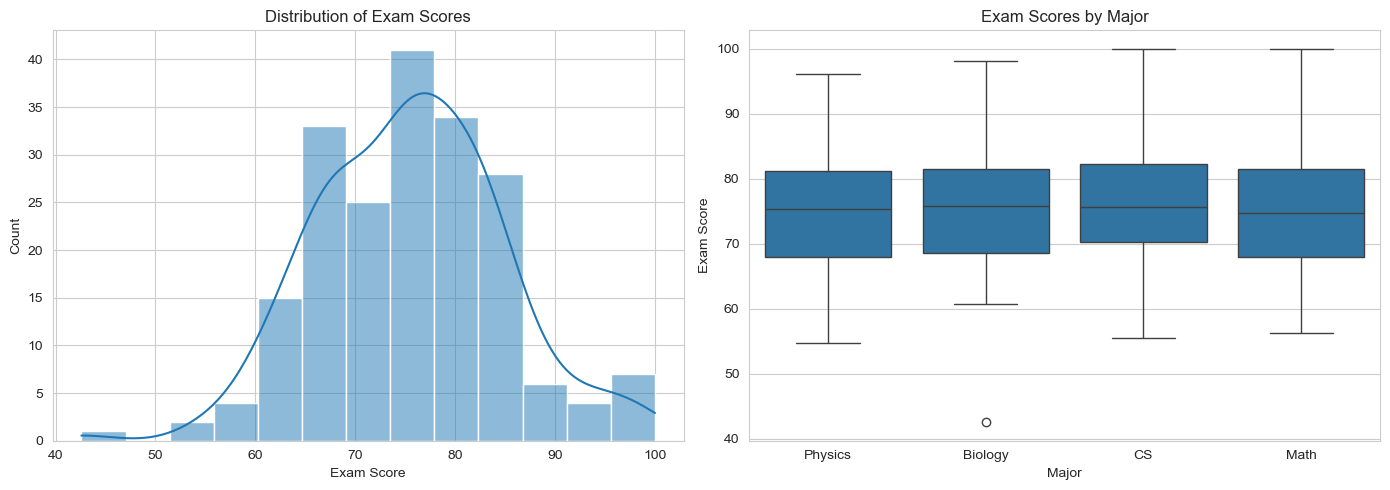

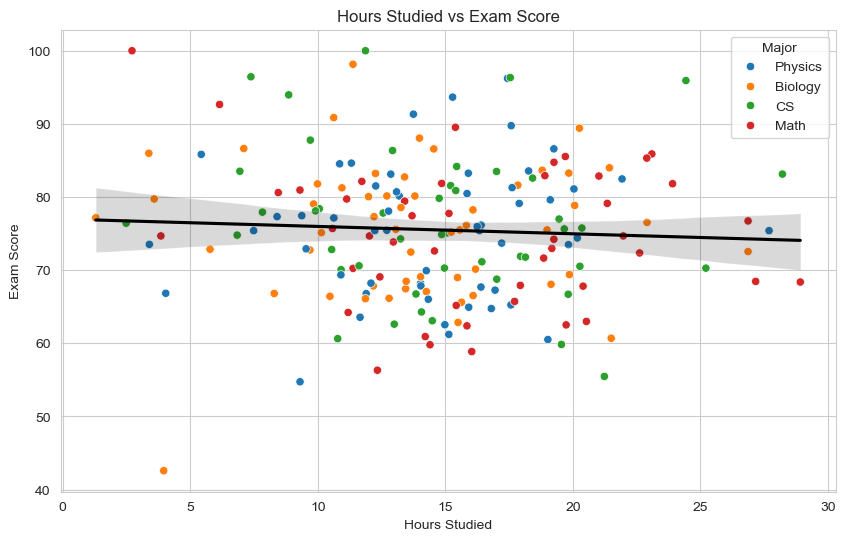

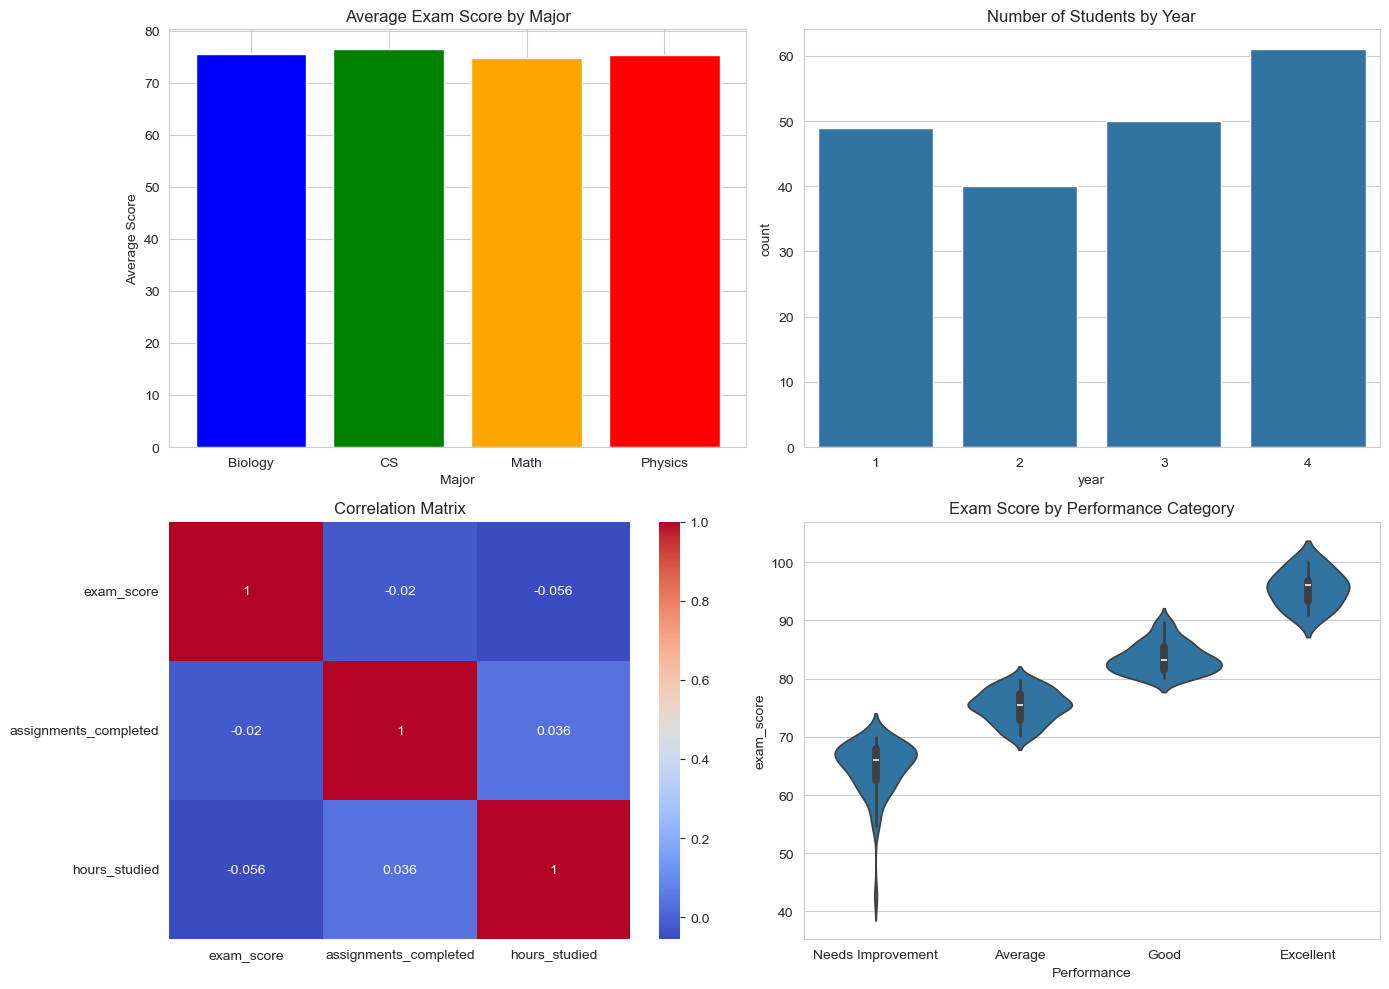

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Task 1: Distribution Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='exam_score', kde=True, ax=ax1)
ax1.set_title('Distribution of Exam Scores')
ax1.set_xlabel('Exam Score')

sns.boxplot(data=df, x='major', y='exam_score', ax=ax2)
ax2.set_title('Exam Scores by Major')
ax2.set_xlabel('Major')
ax2.set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='hours_studied', y='exam_score', hue='major')
sns.regplot(data=df, x='hours_studied', y='exam_score', scatter=False, color='black')
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Major')
plt.show()

# Task 3: Advanced Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart
avg_scores = df.groupby('major')['exam_score'].mean()
axes[0, 0].bar(avg_scores.index, avg_scores.values, color=['blue', 'green', 'orange', 'red'])
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')

# 2. Count plot
sns.countplot(data=df, x='year', ax=axes[0, 1])
axes[0, 1].set_title('Number of Students by Year')

# 3. Heatmap
numeric_cols = df[['exam_score', 'assignments_completed', 'hours_studied']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix')

# 4. Violin plot
sns.violinplot(data=df, x='performance', y='exam_score', ax=axes[1, 1])
axes[1, 1].set_title('Exam Score by Performance Category')
axes[1, 1].set_xlabel('Performance')

plt.tight_layout()
plt.show()

Analysis by Age Group:
           num_customers  avg_income  avg_clv  total_clv
age_group                                               
18-25                 81    50634.02   718.37   58188.06
26-35                 73    48747.15   747.74   54584.92
36-50                160    48516.90   732.80  117247.46
51-70                186    50713.16   762.69  141860.99

Top 10% customers: 50 customers
Their average CLV: $1398.89


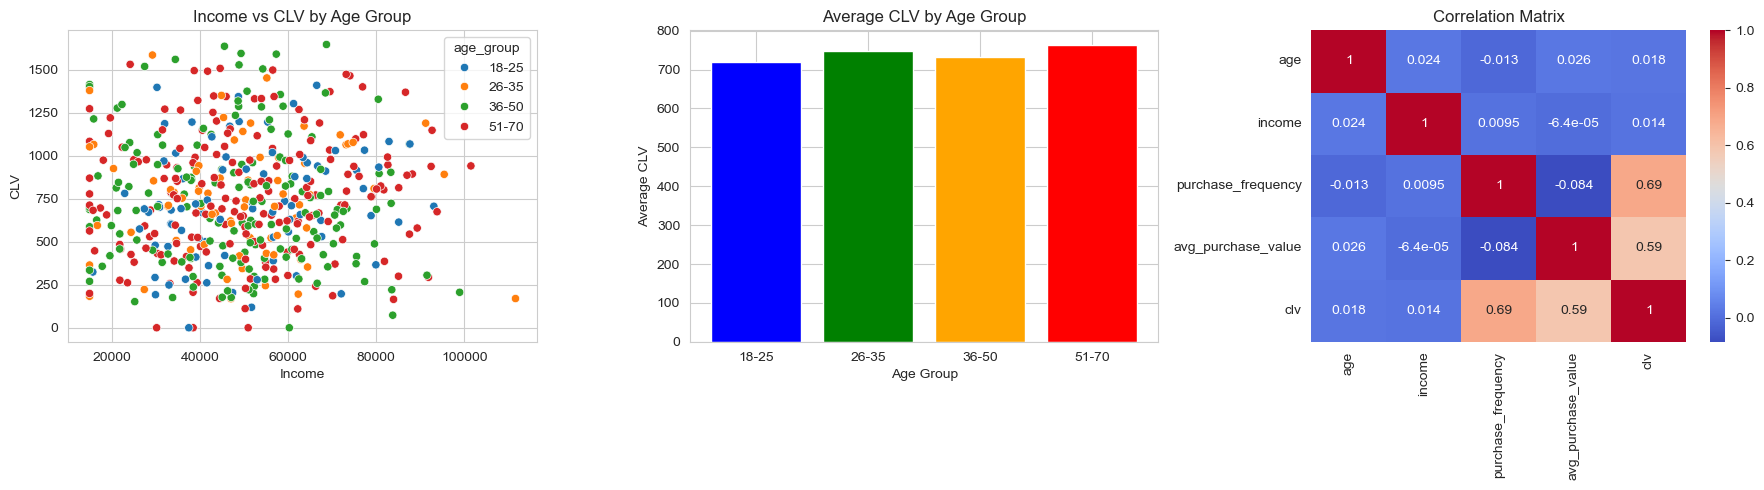

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# Calculate CLV
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['clv'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])

# Age groups
customers['age_group'] = pd.cut(customers['age'], bins=[17, 25, 35, 50, 70], labels=['18-25', '26-35', '36-50', '51-70'])

# Analysis by age group
print("Analysis by Age Group:")
print(customers.groupby('age_group', observed=True).agg(
    num_customers=('clv', 'count'),
    avg_income=('income', 'mean'),
    avg_clv=('clv', 'mean'),
    total_clv=('clv', 'sum')
).round(2))

# Top 10% customers
top_10_percent = customers[customers['clv'] >= customers['clv'].quantile(0.90)]
print(f"\nTop 10% customers: {len(top_10_percent)} customers")
print(f"Their average CLV: ${top_10_percent['clv'].mean():.2f}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter plot
sns.scatterplot(data=customers, x='income', y='clv', hue='age_group', ax=axes[0])
axes[0].set_title('Income vs CLV by Age Group')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('CLV')

# 2. Bar chart
avg_clv = customers.groupby('age_group', observed=True)['clv'].mean()
axes[1].bar(avg_clv.index, avg_clv.values, color=['blue', 'green', 'orange', 'red'])
axes[1].set_title('Average CLV by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average CLV')

# 3. Correlation heatmap
sns.heatmap(customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'clv']].corr(), 
            annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()